In [1]:
import os
import torch
import torch.nn.functional as F
from jinyu_utils import jinyu_dataset
from jinyu_utils.jinyu_preprocess_wiki import parse_lines_with_index, merge_subdocs, PATTEN_REG_WIKI

from transformers import AutoTokenizer
from datasets import load_dataset, Dataset
from abc import ABC, abstractmethod

from torch.utils.data import DataLoader

from fastdllm_generate import add_gumbel_noise, get_num_transfer_tokens

from tqdm import tqdm
from modeling_llada_with_budget_and_cachekv import LLaDAModelLM

from datetime import datetime, timezone
from collections import defaultdict

def get_current_time_str():
    return datetime.now(timezone.utc).replace(microsecond=0).isoformat().replace("+00:00", "Z")
# end


/home/exx/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:


'''initialize global constants'''

ID_TOKEN_MASK = 126336 # '|mdm_mask|'
ID_TOKEN_PADDING = 126081 # '|endoftext|'
ID_TOKEN_EOT = 126348 # '|eot_id|'

TYPES_REMASKING = {'truth_top_k', 'random_top_k'}



'''define token encoder function'''

class Tokenizer_(ABC):
    def __init__(self, tokenizer, len_max):
        self.tokenizer = tokenizer
        self.len_max = len_max
    # end

    @abstractmethod
    def _tokenize(self, ds_each):
        pass
    # end

    def __call__(self, ds_each):
        return self._tokenize(ds_each)
    # end
# end

class Tokenizer_wiki_simple(Tokenizer_):

    def _tokenize(self, ds_each):
        ids = self.tokenizer(
            ds_each['text'],
            add_special_tokens=False,               # avoids BOS/EOS being injected by tokenizer
            truncation=(self.len_max is not None),  # truncation and max_length is a pair
            max_length=self.len_max,
            # return_tensors='pt'
        )["input_ids"]


        return {
            'ids_input': ids,
            'length': len(ids)
        }
    # end tokenize
# end


class Collater_(ABC):
    def __init__(self, len_max, len_prompt, len_target, id_mask):
        self.len_max = len_max
        self.len_prompt = len_prompt
        self.len_target = len_target
        self.id_mask = id_mask
    # end

    @abstractmethod
    def _collate(self, ds_batch):
        pass
    # end

    def __call__(self, ds_batch):
        return self._collate(ds_batch)
    # end
# end


class Collater_wiki_simple(Collater_):

    def _collate(self, ds_batch):
        # batch: list of dicts with "input_ids" as python lists
        len_min = min(len(ds_each["ids_input"]) for ds_each in ds_batch)

        ids_input = torch.stack([torch.tensor(ds_each["ids_input"][:len_min], dtype=torch.long) for ds_each in ds_batch], dim=0) # [B, min_len]
        masks_input = torch.zeros_like(ids_input, dtype=bool)
        masks_input[:, self.len_prompt:] = True
        ids_target = torch.where(masks_input, ids_input, self.id_mask)
        ids_input[masks_input] = self.id_mask

        return {
            'ids_prompt_masked_full': ids_input,
            'ids_target_masked_full': ids_target
        }
    # end _collate
# end

def get_refresh_idx(x, len_prompt=0, type_refresh=None):
    
    if type_refresh == 'previous_all':
        return torch.arange(len_prompt, dtype=torch.long, device=x.device)
    # end

    return torch.tensor([0,1], dtype=torch.long, device=x.device)
# end


''' ppl calculation function'''
def calculate_ppl_and_conf(probs_all, mask_target, eps=1e-12):
    # probs_collected = probs_all[mask_target].reshape(mask_target.shape[0], -1)  # [B, K]
    probs_collected = probs_all[mask_target].reshape(-1)  # [B * K]

    # Arithmetic mean confidence (what you currently call mean_prob)
    mean_prob = probs_collected.mean(dim=-1)  # [B]

    # Per-token NLL and per-row PPL (geometric-mean based)
    nll_collected = -torch.log(probs_collected + eps)   # [B, K]
    nll_per = nll_collected.mean(dim=-1)                 # [B]
    ppl_per = torch.exp(nll_per)                        # [B]

    # Geometric mean confidence (this one is directly tied to PPL)
    # geo_prob = torch.exp(torch.log(probs_collected + eps).mean(dim=1))  # [B]
    # And ppl_per == 1 / geo_prob (up to eps effects)

    return ppl_per.item(), mean_prob.item()
# end


@ torch.no_grad()
def get_transfer_index(
    logits: torch.Tensor,
    temperature: float,
    remasking: str,
    mask_index: torch.Tensor,   # (B, L) bool
    x: torch.Tensor,            # (B, L) long
    y: torch.Tensor,            # (B, L) long
    num_transfer_tokens,        # (B,) or (B,1) long tensor, or None when threshold is used
    threshold: float = None,
):
    """
    Returns:
        x0: (B, L) long — proposed tokens
        transfer_index: (B, L) bool — which positions to update this step
    """
    # 1) Sample proposal x0
    # Gumbel-noise for exploration; if temperature==0, add_gumbel_noise should no-op
    logits_with_noise = add_gumbel_noise(logits, temperature=temperature)
    x0 = torch.argmax(logits_with_noise, dim=-1)  # (B, L), long

    # 2) Confidence for chosen tokens (or random)
    p = F.softmax(logits.to(torch.float64), dim=-1)
    x0_p = torch.gather(p, dim=-1, index=y.unsqueeze(-1)).squeeze(-1)  # (B, L), float64
    # x0_p = torch.rand(x0.shape, device=x0.device, dtype=torch.float64)  # (B, L)  # removed by jinyu

    # Only modify masked spots; keep others as original x and set their confidence to -inf
    # TODO: we have error here
    x0 = torch.where(mask_index, x0, x) # mask_index is only this block

    neg_inf = torch.tensor(torch.finfo(x0_p.dtype).min, device=x0.device, dtype=x0_p.dtype)
    confidence = torch.where(mask_index, x0_p, neg_inf)  # (B, L)   # so only the masked part has confidence

    # Ensure shape (B,) long    jinyu: re-calculate num_transfer_token every time(I think)
    if num_transfer_tokens.dim() == 2 and num_transfer_tokens.size(1) == 1:
        num_transfer_tokens = num_transfer_tokens.squeeze(1)
    # end

    num_transfer_tokens = num_transfer_tokens.to(dtype=torch.long, device=confidence.device)
    num_transfer_tokens = torch.clamp(num_transfer_tokens, min=0)   # jinyu: can it be negative???


    # Sort confidences descending (masked positions are valid; others are -inf)
    # idx: (B, L) gives positions in original sequence sorted by confidence
    if remasking == 'random_top_k':
        idx_sorted_random = torch.argsort(
            torch.where(
                mask_index,
                torch.rand(confidence.shape[0], confidence.shape[1], device=confidence.device),
                confidence
            ),
            dim=1,
            descending=True
        )
        idx_sorted = idx_sorted_random  # for your read
    elif remasking == 'truth_top_k':
        idx_sorted = torch.argsort(confidence, dim=1, descending=True)
    else:
        raise NotImplementedError()
    # end

    B, L = confidence.shape
    # Build a mask that is True for the first k[b] columns in each row (sorted order)
    cols = torch.arange(L, device=confidence.device).unsqueeze(0).expand(B, L)   # (B, L)
    k_expanded = num_transfer_tokens.unsqueeze(1).expand(B, L)                   # (B, L)
    select_sorted = cols < k_expanded                                            # (B, L) bool for top k

    # Scatter the sorted True/False back to original column order
    # Use integer scatter then cast to bool (scatter_ on bool can be finicky across versions)
    transfer_int = torch.zeros(B, L, device=confidence.device, dtype=torch.int8) # (B, L)
    transfer_int = transfer_int.scatter(1, idx_sorted, select_sorted.to(torch.int8))
    transfer_index = transfer_int.bool() & mask_index  # ensure we never select unmasked

    return x0, x0_p, transfer_index
# end



In [3]:
'''load dataset first'''
name_dataset = jinyu_dataset.LIST_DATASET[1]
ds = load_dataset(*name_dataset, split='all')
docs, _ = parse_lines_with_index(PATTEN_REG_WIKI, ds['text'])
docs = docs['subdocs']

samples = []
for doc in docs:
    lines_1 = doc['texts']
    paragraph_1 = ' '.join(lines_1)
    lines_remain, titles = merge_subdocs(doc['subdocs'])
    paragraph_remain = ' '.join(lines_remain)
    prefix = paragraph_1
    target = paragraph_remain
    samples.append({'text': paragraph_1 + ' ' + paragraph_remain})
# end

ds_origin = Dataset.from_list([samples[0]])


'''initialize constant hyper-parameters'''
id_model_g = 'GSAI-ML/LLaDA-8B-Base'
id_mask_g = 126336
device_g = 'cuda:0'
size_batch_g = 1


'''load tokenizer'''
tokenizer = AutoTokenizer.from_pretrained(
    id_model_g,
    trust_remote_code=True
)

if tokenizer.padding_side != 'left':
    tokenizer.padding_side = 'left'
# end
assert tokenizer.pad_token_id != 126336


'''load model'''
model_kwargs = {}
model = LLaDAModelLM.from_pretrained(
    id_model_g,
    trust_remote_code=True,
    torch_dtype=torch.bfloat16,
    **model_kwargs
)

model = model.eval().to(device_g)

'''hyper parameter to be set'''

len_prompt_g = 128
len_target_g = 256
num_blocks_g = 4
num_unmask_per_iter_g = 1

'''hyper parameter can be calculated'''
len_max_g = len_prompt_g + len_target_g
size_block_g = int(len_target_g / num_blocks_g)
assert num_unmask_per_iter_g <= size_block_g
steps_g = int(len_target_g / num_unmask_per_iter_g)


'''start to handle dataset based on hyper-parameter'''
ds = ds_origin\
    .filter(lambda x: x["text"] is not None and len(x["text"].strip()) > 0)\
    .map(Tokenizer_wiki_simple(tokenizer, len_max_g), remove_columns=ds_origin.column_names)\
    .filter(lambda x: x["length"] >= len_max_g)\
    .sort("length")
# end

'''prepare dataloader'''
loader = DataLoader(
    ds,
    batch_size=size_batch_g,
    shuffle=False,                 # keep sorted order
    collate_fn=Collater_wiki_simple(len_max_g, len_prompt_g, len_target_g, id_mask_g),
    drop_last=False
)

The argument `trust_remote_code` is to be used with Auto classes. It has no effect here and is ignored.
Filter: 100%|██████████| 1/1 [00:00<00:00, 1015.08 examples/s]


In [11]:
@torch.no_grad()
def run_model_without_budget_and_collect_kv(
    model,
    ids_input_masked_full,
    ids_target_masked_full,
    len_prompt,
    remasking='truth_top_k',
    steps=128,
    gen_length=128,
    block_length=128,
    temperature=0.,
    mask_id=126336,
    is_eval=True,
    cache_kv_previous=True,
):
    
    x, y = ids_input_masked_full, ids_target_masked_full
    B = x.shape[0]

    probs_all = torch.zeros(x.shape, dtype=torch.float64).to(model.device)

    assert gen_length % block_length == 0
    num_blocks = gen_length // block_length

    assert steps % num_blocks == 0
    steps_per_block = steps // num_blocks

    names_hidden = ('_k_previous','_v_previous')
    dict_kv_layer_to_list_sim = {}
    for name_hidden in names_hidden:
        dict_kv_layer_to_list_sim[name_hidden] = defaultdict(list)
    # end

    dict_kv_layer_to_hidden_previous = {}
    for name_hidden in names_hidden:
        dict_kv_layer_to_hidden_previous[name_hidden] = {} # {'k|v': {'0': <hidden>}}
    # end

    for id_block in range(num_blocks):

        position_start = len_prompt + id_block * block_length
        position_end = position_start + block_length
        block_mask_index = (x[:, position_start:position_end] == mask_id)  # (B, block_length)
        num_transfer_tokens = get_num_transfer_tokens(block_mask_index, steps_per_block)  # (B, steps_per_block)

        for step_in_block in range(steps_per_block):
            # Evaluate logits only for current block with cache
            if (x[:, position_start:position_end] == mask_id).sum() == 0:
                break
            # end

            idx_refresh = get_refresh_idx(x, position_start, type_refresh='previous_all') # full prompt is to refresh
            idx_denoising = torch.arange(position_start, position_end,dtype=torch.long, device=x.device)
            idx_current = torch.cat([idx_refresh, idx_denoising])
            x_current = x[:, idx_current]

            output_current = model(
                x_current,
                use_cache=False,
                idx_current=idx_current,
                shape_target=(x.shape[0], position_end, -1),
                cache_kv_previous=cache_kv_previous
            )

            # (B, [refresh|blk])
            logits_current = output_current.logits
            logits_blk = logits_current[:, idx_denoising] # (B, [blk])

            # Mask and quota for this step (all tensor ops)
            mask_blk = (x[:, position_start:position_end] == mask_id)  # (B, block_length)
            blk_x = x[:, position_start:position_end]
            blk_y = y[:, position_start:position_end]
            blk_prob = probs_all[:, position_start:position_end]

            quota_i = num_transfer_tokens[:, step_in_block]  # (B,)
            blk_x0, blk_x0_p, transfer_idx_blk = get_transfer_index(
                logits_blk,
                temperature,
                remasking,
                mask_blk,
                blk_x,
                blk_y,
                quota_i
            )

            blk_x[transfer_idx_blk] = blk_y[transfer_idx_blk] if is_eval else blk_x0[transfer_idx_blk]
            blk_prob[transfer_idx_blk] = blk_x0_p[transfer_idx_blk]


            '''start to collect cached hidden'''
            if not cache_kv_previous:
                continue
            #

            for name_hidden in names_hidden:    # k,v
                for block_transformer in model.model.transformer.blocks[:]:                       # take last all layers
                    id_layer = block_transformer.layer_id

                    if hasattr(block_transformer, name_hidden):
                        cache_current = getattr(block_transformer, name_hidden)

                        if dict_kv_layer_to_hidden_previous[name_hidden].get(id_layer) is None:
                            dict_kv_layer_to_hidden_previous[name_hidden][id_layer] = cache_current
                            continue
                        # end

                        # we have current and last, calculate similarity
                        cache_last = dict_kv_layer_to_hidden_previous[name_hidden][id_layer]
                        dict_kv_layer_to_hidden_previous[name_hidden][id_layer] = cache_current  # udpate cache

                        if cache_last.shape[1] < cache_current.shape[1]:
                            cache_last = torch.cat([cache_last, cache_current[:, cache_last.shape[1]:, :]], dim=1)  # evaluated at 0309
                        # end

                        sim_neighbour = F.cosine_similarity(cache_current, cache_last, dim=-1).clamp(-1.0, 1.0) # evaluated at 0309
                        
                        if sim_neighbour.shape[-1] < x.shape[-1]:
                            sim_neighbour_padded = F.pad(
                                sim_neighbour,
                                (0, x.shape[-1]-sim_neighbour.shape[-1]),
                                value=1.0
                            ).squeeze(0)
                        else:
                            sim_neighbour_padded = sim_neighbour.squeeze(0)
                        # end

                        dict_kv_layer_to_list_sim[name_hidden][id_layer].append(sim_neighbour_padded)
                    # end
                # end
            # end
        # end for step
    # end for block, diffusion ends


    result_sim = None
    if  cache_kv_previous:
        dict_kv_sim_final = {}

        for name_hidden in names_hidden:
            ids_layer_sorted = sorted(list(dict_kv_layer_to_list_sim[name_hidden].keys()))

            list_layer_list_matrix_sim_step_token = [torch.stack(dict_kv_layer_to_list_sim[name_hidden][id_layer], 0) for id_layer in ids_layer_sorted]
            matrix_sim_layer_step_token = torch.stack(list_layer_list_matrix_sim_step_token, 0)
            matrix_sim_step_layer_token = matrix_sim_layer_step_token.transpose(0,1)
            dict_kv_sim_final[name_hidden] = matrix_sim_step_layer_token
        # end
        result_sim = dict_kv_sim_final
    # end


    return probs_all, y != mask_id, result_sim
# end

In [12]:
folder_output='sims_kv_test2'
os.makedirs(folder_output, exist_ok=True)

'''start the evaluation process'''
for id_batch, batch in enumerate(tqdm(loader)):

    _, _, dict_kv_sim = run_model_without_budget_and_collect_kv(
        model,
        batch['ids_prompt_masked_full'].to(device_g),
        batch['ids_target_masked_full'].to(device_g),
        len_prompt_g,
        remasking='truth_top_k',
        steps=steps_g,
        gen_length=len_target_g,
        block_length=size_block_g,
        mask_id=id_mask_g,
    )

    for name_hidden, matrix_sim_step_layer_token in dict_kv_sim.items():
        name_file = f'batch_{id_batch}{name_hidden}.pt'
        path_file = os.path.join(folder_output, name_file)
        print(f'saving {path_file} with shape {matrix_sim_step_layer_token.shape}')
        torch.save(matrix_sim_step_layer_token.detach().float().cpu(), path_file)
    # end

# end for

100%|██████████| 1/1 [00:10<00:00, 10.95s/it]

saving sims_kv_test2/batch_0_k_previous.pt with shape torch.Size([255, 32, 384])
saving sims_kv_test2/batch_0_v_previous.pt with shape torch.Size([255, 32, 384])


In [6]:
import torch
import matplotlib.pyplot as plt

def plot_step_similarity_heatmap(sim_tensor, step_idx, title=None, savepath=None,
                                 vmin=-1.0, vmax=1.0):
    """
    sim_tensor: torch.Tensor of shape [steps, layers, tokens]
    step_idx: which step to visualize
    """
    if sim_tensor.ndim != 3:
        raise ValueError(f"Expected 3D tensor [steps, layers, tokens], got shape {tuple(sim_tensor.shape)}")

    num_steps, num_layers, num_tokens = sim_tensor.shape

    if not (0 <= step_idx < num_steps):
        raise IndexError(f"step_idx={step_idx} out of range [0, {num_steps-1}]")

    # Slice one step: [layers, tokens]
    mat = sim_tensor[step_idx].detach().float().cpu()

    plt.figure(figsize=(10, 6), dpi=150)
    im = plt.imshow(
        mat.numpy(),
        aspect="auto",
        cmap="RdYlGn",   # red -> yellow -> green
        vmin=vmin,
        vmax=vmax,
    )
    plt.colorbar(im, fraction=0.046, pad=0.04, label="cosine similarity")

    plt.xlabel("token position")
    plt.ylabel("layer number")

    if title is None:
        title = f"Similarity heatmap at step {step_idx} (comparing step {step_idx+1} to step {step_idx})"
    plt.title(title)

    # optional sparse ticks
    xtick_stride = max(1, num_tokens // 8)
    ytick_stride = max(1, num_layers // 8)
    plt.xticks(range(0, num_tokens, xtick_stride))
    plt.yticks(range(0, num_layers, ytick_stride))

    plt.tight_layout()

    if savepath:
        plt.savefig(savepath)

    plt.show()

In [ ]:
import torch
import matplotlib.pyplot as plt

def plot_accumulated_change_heatmap(
    sim_tensor,
    reduce_mode="sum",          # "sum", "mean", "max"
    use_normalized_change=False, # False: 1-sim, True: (1-sim)/2
    reverse_x=False,
    title=None,
    savepath=None,
):
    """
    sim_tensor: [steps, layers, tokens]
      value[s, l, t] = cosine similarity for token t at layer l between step s+1 and step s

    Output heatmap:
      x axis = token position
      y axis = step
      value = accumulated change across layers
    """
    if sim_tensor.ndim != 3:
        raise ValueError(f"Expected [steps, layers, tokens], got {tuple(sim_tensor.shape)}")

    sim_tensor = sim_tensor.detach().float().cpu()

    # convert similarity -> change
    if use_normalized_change:
        change = (1.0 - sim_tensor) / 2.0   # if cosine similarity is in [-1, 1]
    else:
        change = 1.0 - sim_tensor           # simple dissimilarity

    # reduce across layers: [steps, tokens]
    if reduce_mode == "sum":
        mat = change.sum(dim=1)
    elif reduce_mode == "mean":
        mat = change.mean(dim=1)
    elif reduce_mode == "max":
        mat = change.max(dim=1).values
    elif reduce_mode == "prod":
        mat = 1.0 - torch.abs(sim_tensor).prod(dim=1)
    else:
        raise ValueError(f"Unknown reduce_mode: {reduce_mode}")

    num_steps, num_tokens = mat.shape



    plt.figure(figsize=(10, 6), dpi=150)
    im = plt.imshow(mat.numpy(), aspect="auto", cmap="RdYlGn_r")
    plt.colorbar(im, fraction=0.046, pad=0.04, label="accumulated change across layers")

    plt.xlabel("token position" + (" (reversed)" if reverse_x else ""))
    plt.ylabel("step")

    if title is None:
        title = f"Accumulated change heatmap across layers ({reduce_mode})"
    plt.title(title)

    # sparse ticks
    xtick_stride = max(1, num_tokens // 8)
    ytick_stride = max(1, num_steps // 8)

    xticks = list(range(0, num_tokens, xtick_stride))
    plt.xticks(xticks)
    plt.yticks(list(range(0, num_steps, ytick_stride)))
    plt.tight_layout()

    if savepath:
        plt.savefig(savepath)

    plt.show()

    return mat  # [steps, tokens]

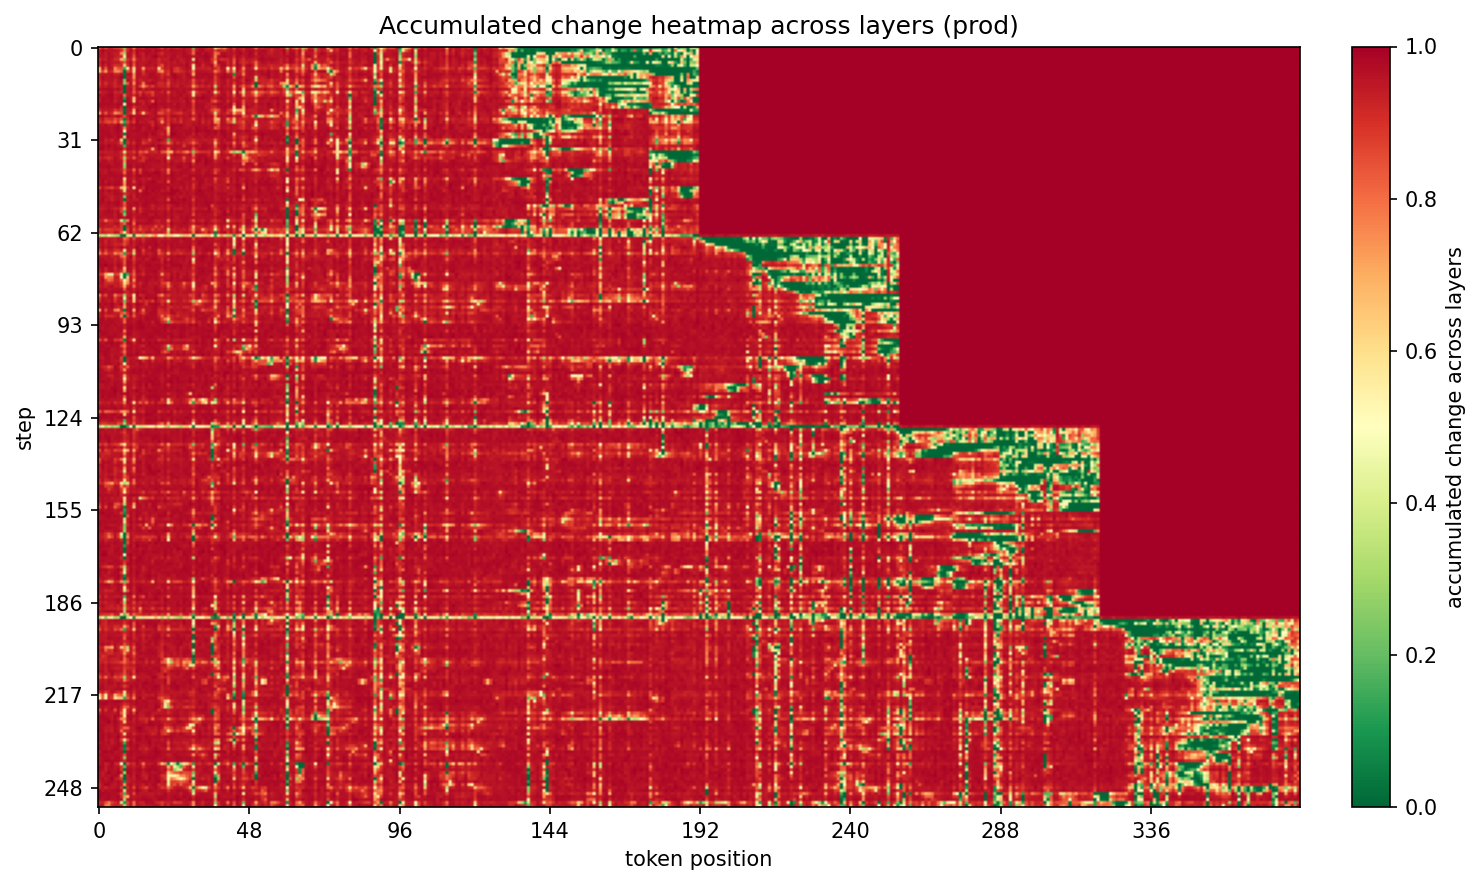

In [28]:
value = torch.load(f'{folder_output}/batch_0_v_previous.pt')


# plot_step_similarity_heatmap(
#     sim_tensor=value,
#     step_idx=63
# )

mat = plot_accumulated_change_heatmap(
    sim_tensor=value,
    reduce_mode="prod",
    use_normalized_change=False
)